# Did you like the movie? - Simple Linear Regression

In this stage we will perform a simple linear regression analysis in order to predict a movie's revenue based on the budget assigned to the movie production. We will present two approaches: using `sci-kit learn` and `statsmodels`, so we can compare both techniques and decide which one is best suited for our needs.

## Libraries

These are the libraries used in this analysis, together with some setup options:

In [1]:
# Data wrangling
# ==============================================================================
import pandas as pd
import numpy as np
from patsy.builtins import Q

In [2]:
# Plots
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

In [3]:
# Preprocessing and modeling
# ==============================================================================
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

In [4]:
# Configuring matplotlib and seaborn
# ==========================================================================bb====
from matplotlib.colors import ListedColormap
plt.rcParams['savefig.bbox'] = "tight"
sns.set_style('darkgrid') # or plt.style.use('ggplot')
sns.set_palette('tab20')

## Loading the dataset

We load our dataset, and from it we create a new dataframe with columns `Metacritic` and `Rotten_Tomatoes`.

In [5]:
movies_Metacritic = pd.read_csv('Team6_final.csv', index_col='Title')
movies_Metacritic.columns

Index(['Year', 'Runtime', 'Genre', 'Budget', 'Revenue', 'Personal', 'IMDb',
       'Rotten_Tomatoes', 'Metacritic', 'Filmaffinity', 'Fans'],
      dtype='object')

In [6]:
movies_Metacritic = movies_Metacritic[['Metacritic', 'Rotten_Tomatoes']]
movies_Metacritic.head()

,Metacritic,Rotten_Tomatoes
Title,,
10 Things I Hate About You,70,71
28 Days Later,73,87
A Star Is Born,88,90
Adaptation (Ladron De Orquideas),83,91
Alien: Romulus,64,80


One parameter that helps determine whether our analysis is valid is the average value of the variable we aim to predict. In this case, that variable is `Rotten_Tomatoes`.

In [7]:
mean_predicted_variable = movies_Metacritic['Rotten_Tomatoes'].mean()
mean_predicted_variable

np.float64(88.93788819875776)

In [8]:
movies_Metacritic.describe()

,Metacritic,Rotten_Tomatoes
count,161.000000,161.000000
mean,79.180124,88.937888
std,10.488022,7.826788
min,55.000000,63.000000
25%,71.000000,85.000000
50%,80.000000,91.000000
75%,87.000000,94.000000
max,100.000000,100.000000


First, we store it in a variable using the ".mean()" function; then we display the average value of that variable and confirm it afterward using the ".describe()" function, where the mean values match. Mean = 88.94

## Graphical analysis

First of all, we plot the data in order to see if there is a relation between the variables and calculate correlation coefficients.

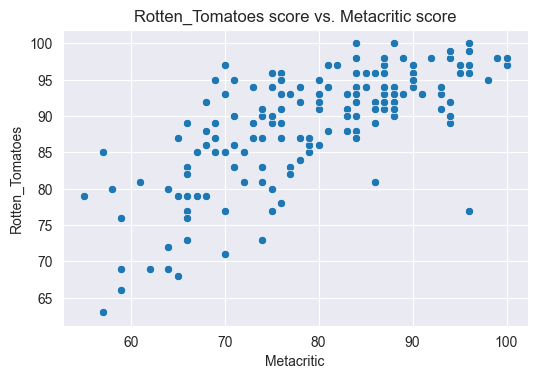

In [9]:
# Scatter plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(6, 3.84))

sns.scatterplot(
    data = movies_Metacritic,
    x    = 'Metacritic',
    y    = 'Rotten_Tomatoes',
    ax   = ax
)

ax.set(title='Rotten_Tomatoes score vs. Metacritic score', xlabel='Metacritic', ylabel='Rotten_Tomatoes');

In [10]:
# Linear correlation
# ==============================================================================
corr_test = pearsonr(x = movies_Metacritic['Metacritic'], y =  movies_Metacritic['Rotten_Tomatoes'])
print("Pearson correlation coefficient: ", corr_test[0])
print("P-value: ", corr_test[1])

Pearson correlation coefficient:  0.7119535534163316
P-value:  3.430863323575644e-26


The graph and the correlation test show a linear relation, with a relatively high intensity (r = 0.71) and high significance level (p-value = 3.43e-26). Thus, we can proceed to generate a linear regression model so we can predict the rating of Rotten_Tomatoes as a function of the rating of Metacritic.

## Fitting the model

Let's fit a model with `Rotten_Tomatoes` as the response variable, and `Metacritic` as the predictor. In order to do this, we split the data in two groups, a training set and a test set. We will use the **statsmodels** library. **Statsmodels** provides two ways of training the model:

- Giving a formula for the model and feeding it with a DataFrame for the training test that includes the response variable and the predictors. This is similar to the method used in R.

- Giving two matrices, a predictor matrix and a response matrix.

Since both approaches gives the same outcome, we will use the formula approach, both with and without intercept.

We begin by splitting the dataframe into two: a training set which is used for fitting the model, and a test set which is used to validate it. After we have fitted and validated the model, we evaluate its predicting strength by calculating the *root mean squared error (`rmse`)*, which is a measure of a distance between the real data and the predictions. As a rule of thumb the `rmse` must be no greater than 10% of the mean of the predicted variable.

In [201]:
# Train-test Splitting
# ==============================================================================
X = movies_Metacritic[['Metacritic']]
y = movies_Metacritic['Rotten_Tomatoes']

X_train, X_test, y_train, y_test = train_test_split(
                                        X.values.reshape(-1,1),
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 185,
                                        shuffle      = True
                                    )
X_train[:5]

array([[58],
       [71],
       [76],
       [65],
       [84]])

These numbers are the first five Metacritic scores in the training set after the data was shuffled. Each value represents one movie. The scores are shown as a single-column matrix because the data was reshaped before splitting. The values range from medium to high scores, and repeated numbers like 84 are normal. Since the data was shuffled, the order of the scores does not match the original dataset.

### Preliminary model fitting using `scikit-learn`

In [202]:
# Model fitting using scikit-learn
# ==============================================================================
model_sk = LinearRegression()
model_sk.fit(X = X_train.reshape(-1, 1), y = y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


The linear regression model was successfully fitted using scikit-learn, with Metacritic as the predictor for Rotten_Tomatoes. The model includes an intercept and keeps the original data unchanged. Its settings are standard, allowing the slope to be either positive or negative. Overall, the model is now ready to be evaluated and used for predictions.

In [203]:
# Model summary
# ==============================================================================
print("Intercept:", model_sk.intercept_[0])
print("Coefficient:", list(zip(X.columns, model_sk.coef_.flatten(), )))
print("R^2 determination coefficient:", model_sk.score(X.values, y))

Intercept: 44.17401628466665
Coefficient: [('Metacritic', np.float64(0.5655896035906655))]
R^2 determination coefficient: 0.5047605674441096


Once we trained the model, we evaluate its predictive strength using the test set.

In [204]:
# Model error test 
# ==============================================================================
predictions = model_sk.predict(X = X_test)
print(predictions[0:3,])

rmse = root_mean_squared_error(
        y_true  = y_test,
        y_pred  = predictions
       )
print("")
print(f"The test error (rmse) is {rmse}, which is {rmse/mean_predicted_variable*100:.2f}% of the mean of `Rotten_Tomatoes`.")

[[88.29000536]
 [97.90502863]
 [92.24913259]]

The test error (rmse) is 4.1373333629394615, which is 4.65% of the mean of `Rotten_Tomatoes`.


In [205]:
print(y_test[0:3])

[[87]
 [97]
 [94]]


We used the model_sk.predict() function to generate predictions, and then we saved these values in the predictions variable, which stores the model’s predicted Rotten_Tomatoes values, and rmse, which stores the computed error. The function used to calculate the error was root_mean_squared_error(). The RMSE is about 5.1960, meaning the model’s predictions differ from the real Rotten_Tomatoes scores by around five points on average. This represents only 5.84% of the mean Rotten_Tomatoes value, showing that the model predicts fairly well.

### Model fitting using `statsmodels`

Now we performed a more complete model fitting using the `statsmodels` library. 

The linear regression implementation in **Statsmodels** is more complete than that of **Scikit-learn** since, in addition to fitting the model, we can estimate the necessary test statistics and analyses for verifying that model conditions are satisfied. **Statsmodels** provides two ways of training the model:

- Giving a formula for the model and feeding it with a `DataFrame` for the training test that includes the response variable and the predictors. This is similar to the method used in **R**.

- Giving two matrices, a predictor matrix and a response matrix. This is similar to the method used with **Scikit-learn**, only that the predictor matrix needs to have all 1s as the first column.

The outcome of our analisys is a table that displays all the important information gathered in the Linear Regression. Here follows an explanation of each item in the table.

- **Dep variable:** The dependent variable in the data.
- **Model and Method:** OLS which stands for Ordinary Least Square. The model tries to find out a linear expression for the dataset which minimizes the sum of residual squares.
- **DF residuals and DF model:** `DF Model` is the number of independent variables. `DF residual` is the difference between the number of observations and the number of features.
- **Covariance type:** Covariance type is typically nonrobust which means there is no elimination of data to calculate the covariance between features. `Covariance` shows how two variables move with respect to each other. If this value is greater than 0, both move in same direction and if it is less than 0, the variables move in opposite directions. Covariance is difference from correlation. Covariance does not provide the strength of the relationship, only the direction of movement whereas the correlation value is normalized and ranges between -1 to +1 and provides the strength of relationship. If we want to obtain robust covariance, we can declare `cov_type=HC0/HC1/HC2/HC3`. However, the `statsmodel` documentation is not that rich to explain all these. HC stands for heteroscedasticity-consistent and HC0 implements the simplest version among all.
- **R-squared:** The R-squared value is the coefficient of determination which indicates the percentage of the variability in the data explained by the selected independent variables.
- **Adj. R-squared:** As we add more and more independent variables to our model, the R-squared value increases but in reality, those variables do not necessarily make any contribution towards explaining the dependent variable. Therefore addition of each unnecessary variables needs some sort of penalty. The original R-squared value is adjusted when there are multiple variables incorporated. In essence, we should always look for adjusted R-squared value while performing multiple linear regression. For a single independent variable, both R-squared and adjusted R-squared value are same.
- **coef** and **std err:** The `coef` column represents the coefficients for each independent variable along with the intercept value. `Std err` is the standard deviation of the corresponding variable's coefficient across all the data points.
- **$t$-values and $P>|t|$:** The $t$-column provides the $t$-values corresponding to each independent variable. $t$-statistics are used to calculate the $p$-values. Typically when $p$-value is less than $0.05$ it indicates a strong evidence against the null hypothesis which states that the corresponding independent variable has no effect on the dependent variable.
- **$F$-statistics:** An $F$-test provides a way to check all the independent variables together to see if any of those are related to the dependent variable. If `Prob(F-statistic)` is greater than $0.05$ there is no evidence of relationship between any of the independent variables with the output. If it is less than $0.05$, we can say that there is at least one variable which is significantly related with the output. However, there may be some cases when `prob(F-statistic)` may be greater than $0.05$ but one of the independent variables shows strong correlation. This is because each $t$-test is carried out with different sets of data whereas the $F$-test checks the combined effect including all variables globally.
- **Log-likelihood:** The `log-likelihood` value is a measure of how good the model fits the given data. It is useful when we compare two or more models. The higher the value of `log-likelihood`, the better the model fits the given data. It can range from negative infinity to positive infinity.
- **AIC and BIC:** AIC, which stands for Akaike’s Information Criteria and was developed by Japanese statistician Hirotugo Akaike, and BIC, which stands for Bayesian Information Criteria, are also used as criteria for model robustness. The goal is to minimize these values to get a better model.
- **Omnibus and Prob(Omnibus):** Omnibus test checks the normality of the residuals once the model is deployed. If the value is zero, it means the residuals are perfectly normal. For a model to be robust, besides checking $R$-squared and other rubrics, the residual distribution is also required to be normal. In other words, the residual should not follow any pattern when plotted against the fitted values.
- **Skew and Kurtosis:** Skew values tells us the skewness of the residual distribution. Normally distributed variables have $0$ skew value, right-skewed distributions have positive skew values and lefth-skewed distributions have negative skew values. Kurtosis is a measure of light-tailed or heavy-tailed distribution compared to the normal distribution. High kurtosis indicates the distribution is too narrow and low kurtosis indicates the distribution is too flat. A kurtosis value between $-2$ and $+2$ is good to prove normalcy.
- **Durbin-Watson:** The Durbin-Watson statistic provides a measure of autocorrelation in the residuals. If the residual values are autocorrelated, the model becomes biased. This simply means that one value should not be depending on any of the previous values. An ideal value for this test ranges from $0$ to $4$.
- **Jarque-Bera (JB) and Prob(JB):** Jarque-Bera (JB) and Prob(JB) are similar to Omni test measuring the normalcy of the residuals.
- **Condition Number:** High condition number indicates that possibly there is multicollinearity present in the dataset. If only one variable is used as predictor, this value is low and can be ignored. We can proceed like stepwise regression and see if there is any multicollinearity added when additional variables are included.

We begin by creating training and testing data frames from the training and testing sets we constructed above.

In [206]:
data_train = pd.DataFrame(np.hstack((X_train, y_train)), columns=['Metacritic', 'Rotten_Tomatoes'])
data_test = pd.DataFrame(np.hstack((X_test, y_test)), columns=['Metacritic', 'Rotten_Tomatoes'])

data_train.head()

,Metacritic,Rotten_Tomatoes
0,58,80
1,71,83
2,76,96
3,65,68
4,84,100


We combined the training predictor values (Metacritic) and the training response values (Rotten_Tomatoes) into a single DataFrame called "data_train". We did the same for the test set, creating "data_test". This allows us to view and work with both variables together. The command "data_train.head()" shows the first five rows of the training dataset.

### Model fitting with intercept

In [236]:
# Model fitting using a formula
# ==============================================================================
#modelf = smf.ols(formula = "Q('Rotten_Tomatoes') ~ Q('Metacritic')", data = data_train)
modelf = smf.ols(formula = "Rotten_Tomatoes ~ Metacritic", data = data_train)
modelf = modelf.fit()
modelf.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Rotten_Tomatoes   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     132.6
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           2.09e-21
Time:                        12:43:55   Log-Likelihood:                -406.38
No. Observations:                 128   AIC:                             816.8
Df Residuals:                     126   BIC:                             822.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     44.1740      3.920     11.269      0.000      36.417      51.931
Metacritic     0.5656      0.049     11.516      0.000       0.468       0.663
==============================================================================
Omnibus:                       13.548   Durbin-Watson:                   2.028
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               14.850
Skew:                          -0.714   Prob(JB):                     0.000596
Kurtosis:                       3.863   Cond. No.                         607.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

We need Kurtosis to be between -2 and 2 Dep. Variable, R-squared, prob (f-statistic), Intercept, Metacritic, P>1t1, Kurtosis


We observe that `R^2` is relatively small, so we suspect that the intercept must be zero

### Model fitting without intercept

In [237]:
# Model fitting using a formula
# ==============================================================================

modelf_noint = smf.ols(formula = "Rotten_Tomatoes ~ Metacritic + 0", data = data_train)
modelf_noint = modelf_noint.fit()
modelf_noint.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:        Rotten_Tomatoes   R-squared (uncentered):                   0.992
Model:                            OLS   Adj. R-squared (uncentered):              0.991
Method:                 Least Squares   F-statistic:                          1.493e+04
Date:                Mon, 01 Dec 2025   Prob (F-statistic):                   1.44e-133
Time:                        12:43:57   Log-Likelihood:                         -450.99
No. Observations:                 128   AIC:                                      904.0
Df Residuals:                     127   BIC:                                      906.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Metacritic     1.1143      0.009    122.181      0.000       1.096       1.132
==============================================================================
Omnibus:                        3.186   Durbin-Watson:                   2.177
Prob(Omnibus):                  0.203   Jarque-Bera (JB):                2.778
Skew:                          -0.227   Prob(JB):                        0.249
Kurtosis:                       3.560   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In effect, eliminating the intercept increases `R^2`.

In order to decide whether to include the intercept or not, we perform a residual analysis with each model and choose the one with lower sum of residues. Remember that this sum must be close to zero. But before doing this, let's calculate 95% confidence intervals for both models. This confidence intervals are given in the regression tables above as well.

### Confidence intervals for the coefficients

In [209]:
# Confidence intervals for the coefficients. Model with intercept
# ==============================================================================
modelf.conf_int(alpha=0.05)

,0,1
Intercept,36.416564,51.931468
Metacritic,0.468392,0.662788


These values represent the 95% confidence intervals for the coefficients of the model with an intercept. The intercept is estimated to lie between about 37.64 and 51.99, and the coefficient for Metacritic is between 0.464 and 0.643. This means we are 95% confident that the true effect of Metacritic on Rotten_Tomatoes falls within that range.

In [210]:
# Confidence intervals for the coefficients. Model with no intercept
# ==============================================================================
modelf_noint.conf_int(alpha=0.05)

,0,1
Metacritic,1.096216,1.132309


These are the 95% confidence intervals for the model without an intercept. The coefficient for Metacritic lies between 1.090 and 1.127, meaning we are 95% confident that the true effect of Metacritic on Rotten_Tomatoes falls within this range. Since there is no intercept in this model, only one interval is reported.

## Residual analysis

We perform a basic residual analysis. In order for the model to be adequate, the sum of residues must be close to zero.

### Model with intercept

In [211]:
# Residual analysis
# ==============================================================================
y_train = y_train.flatten()
prediction_train = modelf.predict(exog = data_train)
residues_train   = prediction_train - y_train

In [212]:
residues_train.sum()

np.float64(-4.533262654149439e-12)

In [213]:
(residues_train.min(),residues_train.max())

(np.float64(-13.234711463986798), np.float64(21.4706182293705))

### Model with no intercept

In [214]:
# Residual analysis
# ==============================================================================
y_train = y_train.flatten()
prediction_train_noint = modelf_noint.predict(exog = data_train)
residues_train_noint   = prediction_train_noint - y_train

In [215]:
residues_train_noint.sum()

np.float64(-97.86066149821438)

In [216]:
(residues_train_noint.min(),residues_train_noint.max())

(np.float64(-19.001604256430824), np.float64(29.969228448323435))

We observe that the sum of residues in the model with intercept is close to zero, while that of the model without intercept is pretty high in the negative direction. This implies that the model with no intercept underpredicts our response variable. Thus, we will keep the model with intercept, and check for normality and homocedasticity.

### Graphs

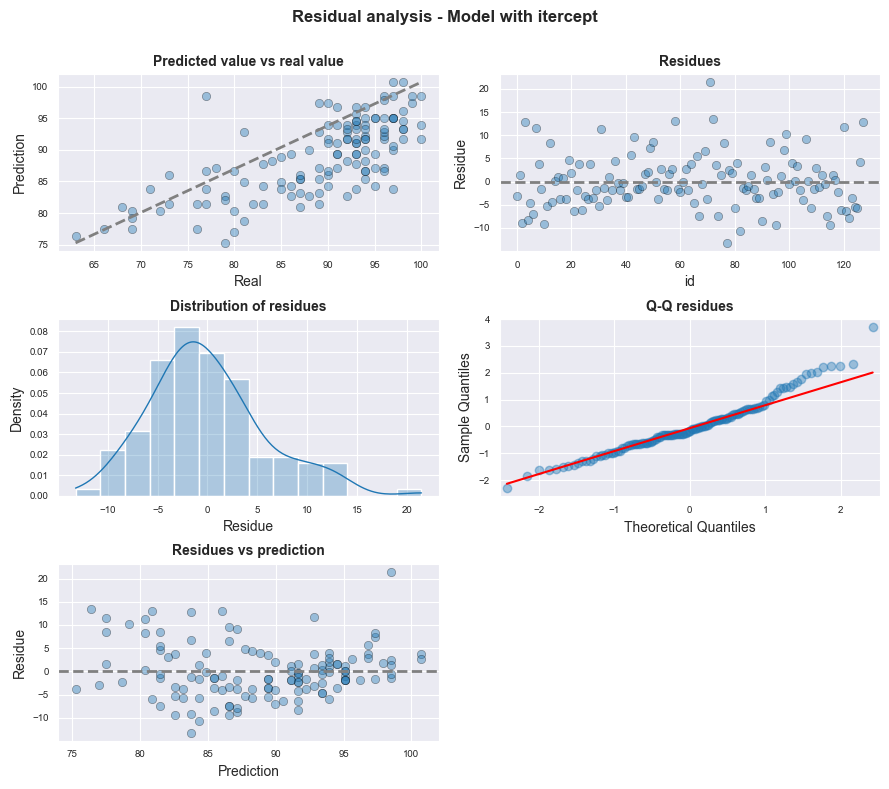

In [217]:
# Graphs
# ==============================================================================
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(9, 8))

# axes[0,0]
sns.scatterplot(
    x          = y_train,
    y          = prediction_train,
    edgecolors =(0, 0, 0),
    alpha      = 0.4,
    ax         = axes[0, 0]
)

points = [(y_train.min(),prediction_train.min()), (y_train.max(), prediction_train.max())]  # x, y coordinates
line_data = pd.DataFrame(points, columns=['x', 'y'])
sns.lineplot(
    x          = 'x',
    y          = 'y',
    data       = line_data, 
    linestyle  = '--', 
    color      = 'gray', 
    lw         = 2,
    ax         = axes[0, 0]
)

axes[0, 0].set_title('Predicted value vs real value', fontsize = 10, fontweight = "bold")
axes[0, 0].set_xlabel('Real')
axes[0, 0].set_ylabel('Prediction')
axes[0, 0].tick_params(labelsize = 7)

# axes[0,1]
sns.scatterplot(
    x          = list(range(len(y_train))),
    y          = residues_train,
    edgecolors = (0, 0, 0),
    alpha      = 0.4,
    ax         = axes[0, 1]
)

axes[0, 1].axhline(y = 0, linestyle = '--', color = 'gray', lw=2)
axes[0, 1].set_title('Residues', fontsize = 10, fontweight = "bold")
axes[0, 1].set_xlabel('id')
axes[0, 1].set_ylabel('Residue')
axes[0, 1].tick_params(labelsize = 7)

# axes[1, 0]
sns.histplot(
    data     = residues_train,
    stat     = "density",
    kde      = True,
    line_kws = {'linewidth': 1},
    alpha    = 0.3,
    ax       = axes[1, 0]
)

axes[1, 0].set_title('Distribution of residues', fontsize = 10, fontweight = "bold")
axes[1, 0].set_xlabel("Residue")
axes[1, 0].tick_params(labelsize = 7)

# axes[1, 1]
sm.qqplot(
    residues_train,
    fit   = True,
    line  = 'q',
    ax    = axes[1, 1], 
    alpha = 0.4,
    lw    = 2
)

axes[1, 1].set_title('Q-Q residues', fontsize = 10, fontweight = "bold")
axes[1, 1].tick_params(labelsize = 7)

# axes[2, 0]
sns.scatterplot(
    x          = prediction_train,
    y          = residues_train,
    edgecolors = (0, 0, 0),
    alpha      = 0.4,
    ax         = axes[2, 0]
)

axes[2, 0].axhline(y = 0, linestyle = '--', color = 'grey', lw=2)
axes[2, 0].set_title('Residues vs prediction', fontsize = 10, fontweight = "bold")
axes[2, 0].set_xlabel('Prediction')
axes[2, 0].set_ylabel('Residue')
axes[2, 0].tick_params(labelsize = 7)

# Eliminate empty axes
fig.delaxes(axes[2,1])

fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Residual analysis - Model with itercept', fontsize = 12, fontweight = "bold");

We observe that the residues are distributed randomly both when plotted in the order they appear and in order of increasing prediction value, which indicates that homoscedasticity is satisfied. However, both the histogram and the Q-Q plot show that the residue distribution is not quite normal, being skewed a little to the right. We check for normality next.

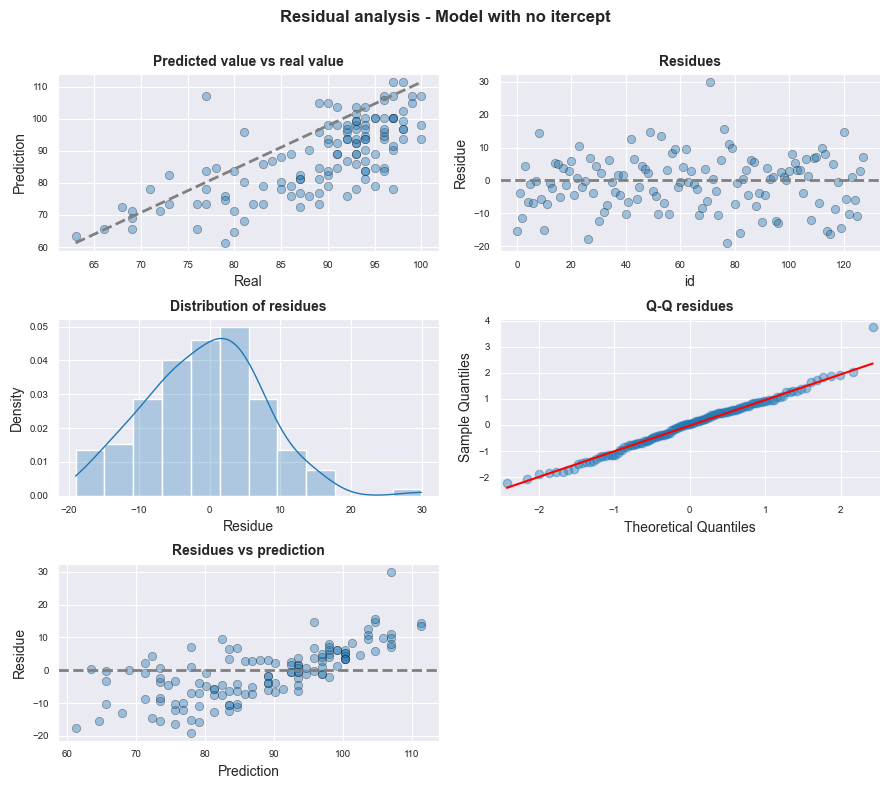

In [226]:
# Graphs
# ==============================================================================
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(9, 8))

# axes[0,0]
sns.scatterplot(
    x          = y_train,
    y          = prediction_train_noint,
    edgecolors =(0, 0, 0),
    alpha      = 0.4,
    ax         = axes[0, 0]
)

points = [(y_train.min(),prediction_train_noint.min()), (y_train.max(), prediction_train_noint.max())]  # x, y coordinates
line_data = pd.DataFrame(points, columns=['x', 'y'])
sns.lineplot(
    x          = 'x',
    y          = 'y',
    data       = line_data, 
    linestyle  = '--', 
    color      = 'gray', 
    lw         = 2,
    ax         = axes[0, 0]
)

axes[0, 0].set_title('Predicted value vs real value', fontsize = 10, fontweight = "bold")
axes[0, 0].set_xlabel('Real')
axes[0, 0].set_ylabel('Prediction')
axes[0, 0].tick_params(labelsize = 7)

# axes[0,1]
sns.scatterplot(
    x          = list(range(len(y_train))),
    y          = residues_train_noint,
    edgecolors = (0, 0, 0),
    alpha      = 0.4,
    ax         = axes[0, 1]
)

axes[0, 1].axhline(y = 0, linestyle = '--', color = 'gray', lw=2)
axes[0, 1].set_title('Residues', fontsize = 10, fontweight = "bold")
axes[0, 1].set_xlabel('id')
axes[0, 1].set_ylabel('Residue')
axes[0, 1].tick_params(labelsize = 7)

# axes[1, 0]
sns.histplot(
    data     = residues_train_noint,
    stat     = "density",
    kde      = True,
    line_kws = {'linewidth': 1},
    alpha    = 0.3,
    ax       = axes[1, 0]
)

axes[1, 0].set_title('Distribution of residues', fontsize = 10, fontweight = "bold")
axes[1, 0].set_xlabel("Residue")
axes[1, 0].tick_params(labelsize = 7)

# axes[1, 1]
sm.qqplot(
    residues_train_noint,
    fit   = True,
    line  = 'q',
    ax    = axes[1, 1], 
    alpha = 0.4,
    lw    = 2
)

axes[1, 1].set_title('Q-Q residues', fontsize = 10, fontweight = "bold")
axes[1, 1].tick_params(labelsize = 7)

# axes[2, 0]
sns.scatterplot(
    x          = prediction_train_noint,
    y          = residues_train_noint,
    edgecolors = (0, 0, 0),
    alpha      = 0.4,
    ax         = axes[2, 0]
)

axes[2, 0].axhline(y = 0, linestyle = '--', color = 'grey', lw=2)
axes[2, 0].set_title('Residues vs prediction', fontsize = 10, fontweight = "bold")
axes[2, 0].set_xlabel('Prediction')
axes[2, 0].set_ylabel('Residue')
axes[2, 0].tick_params(labelsize = 7)

# Eliminate empty axes
fig.delaxes(axes[2,1])

fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Residual analysis - Model with no itercept', fontsize = 12, fontweight = "bold");

### Normality test

We now verify if the residues follow a normal distribution using to statistical tests: *Shapiro-Wilk test* and *D'Agostino's K-squared test*. The latter includes a summary from **Statsmodels** with the name *Omnibus*.

On both tests, the null hypothesis considers that the data follows a normal distribution. Hence, if the *$p$-value* is not smaller than the selected significance level *alpha* there is no evidence to reject the statement that the data is normally distributed.

#### Model with intercept

In [219]:
# Shapiro-Wilk test
# ==============================================================================
shapiro, p_value = shapiro_test = stats.shapiro(residues_train)
print(f"Statistic= {shapiro}, p-value = {p_value}")

Statistic= 0.9668580835832408, p-value = 0.0031648213432736226


In [220]:
# D'Agostino's K-squared test
# ==============================================================================
k2, p_value = stats.normaltest(residues_train)#prediction_train = modelf.predict(exog = X_train)

print(f"Statistic= {k2}, p-value = {p_value}")

Statistic= 13.547978279370128, p-value = 0.0011431254562602369


We observe that, in effect, residues aren't distributed normally, since both `p_values` are smaller than -alpha-=0.05. This agrees with the omnibus, skewness and kurtosis values from the regression table.

This indicates that a linear regression model might be adequate for our variables, but we should consider using other kinds of regression. 

#### Model with no intercept

In [221]:
# Shapiro-Wilk test
# ==============================================================================
shapiro, p_value = shapiro_test = stats.shapiro(residues_train_noint)
print(f"Statistic= {shapiro}, p-value = {p_value}")

Statistic= 0.9855871782678889, p-value = 0.19538989701277626


In [222]:
# D'Agostino's K-squared test
# ==============================================================================
k2, p_value = stats.normaltest(residues_train_noint)
print(f"Statistic= {k2}, p-value = {p_value}")

Statistic= 3.1857950343819628, p-value = 0.20333558898186593


We observe that, in this case, residues are distributed normally, since both `p_values` are larger than -alpha-=0.05. This agrees with the omnibus, skewness and kurtosis values from the regression table.

This indicates that a linear regression model with no intercept might be adequate for our variables, but we should consider using other kinds of regression. However, for the purposes of our project, we will continue using our linear model.

## Predictions

Now that we have trained our model, we can obtain predictions for new data. Models from **statsmodels** allow us to calculate predictions in two ways:

- `.predict()`: only gives predicted values.

- `.get_prediction().summary_frame()`: gives confidence intervals in addition to predicted values.

In [227]:
# Predictions with 95% confidence intervals, model with intercept
# ==============================================================================
predictions = modelf.get_prediction(exog = data_train).summary_frame(alpha=0.05)
predictions.head(4)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,76.978213,1.158311,74.685949,79.270477,65.206654,88.749773
1,84.330878,0.651835,83.040915,85.620841,72.712826,95.948931
2,87.158826,0.537945,86.094249,88.223403,75.563635,98.754017
3,80.937341,0.864123,79.227267,82.647414,69.265173,92.609508


In [228]:
# Predictions with 95% confidence intervals, model with no intercept
# ==============================================================================
predictions_noint = modelf_noint.get_prediction(exog = data_train).summary_frame(alpha=0.05)
predictions_noint.head(4)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,64.627242,0.528947,63.580551,65.673933,48.298540,80.955945
1,79.112659,0.647504,77.831364,80.393953,62.767241,95.458076
2,84.683973,0.693103,83.312446,86.055499,68.331234,101.036711
3,72.427082,0.592786,71.254066,73.600098,56.089795,88.764368


## Graphical representation

Now, we plot the least-squares regression line, as well as upper and lower limits for confidence intervals. With this graph it is possible to identify a region for the *mean* value of the response variable.

#### Model with intercept

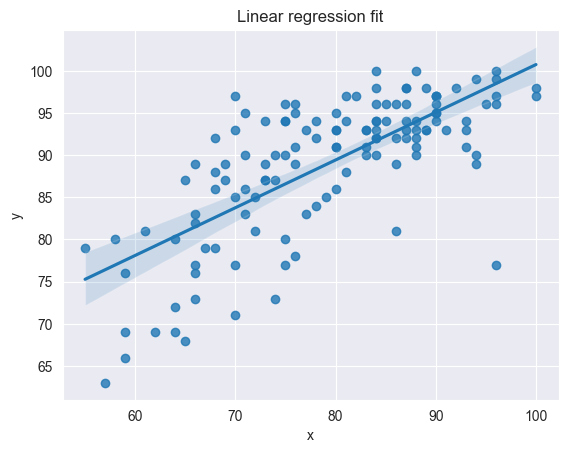

In [229]:
# Predictions with 95% confidence intervals
# ==============================================================================
predictions = modelf.get_prediction(exog = data_train).summary_frame(alpha=0.05)
predictions['x'] = X_train[:, 0]
predictions['y'] = y_train
predictions = predictions.sort_values('x')

# Graph
# ==============================================================================
sns.regplot(
    x     = 'x',
    y     = 'y',
    data  = predictions,
).set_title('Linear regression fit');

#### Model with no intercept

In [230]:
predictions

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper,x,y
26,75.281444,1.291915,72.724782,77.838107,63.455555,87.107334,55,79
72,76.412624,1.202489,74.032933,78.792315,64.623728,88.201520,57,63
0,76.978213,1.158311,74.685949,79.270477,65.206654,88.749773,58,80
7,77.543803,1.114547,75.338147,79.749458,65.788802,89.298804,59,66
50,77.543803,1.114547,75.338147,79.749458,65.788802,89.298804,59,69
...,...,...,...,...,...,...,...,...
78,98.470618,0.976487,96.538179,100.403058,86.763806,110.177431,96,96
113,98.470618,0.976487,96.538179,100.403058,86.763806,110.177431,96,99
112,98.470618,0.976487,96.538179,100.403058,86.763806,110.177431,96,97
53,100.732977,1.148015,98.461088,103.004865,88.965368,112.500585,100,98


In [231]:
predictions_noint

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,64.627242,0.528947,63.580551,65.673933,48.298540,80.955945
1,79.112659,0.647504,77.831364,80.393953,62.767241,95.458076
2,84.683973,0.693103,83.312446,86.055499,68.331234,101.036711
3,72.427082,0.592786,71.254066,73.600098,56.089795,88.764368
4,93.598075,0.766062,92.082177,95.113973,77.232596,109.963554
...,...,...,...,...,...,...
123,99.169389,0.811661,97.563259,100.775519,82.795305,115.543472
124,89.141024,0.729582,87.697312,90.584736,72.782073,105.499974
125,79.112659,0.647504,77.831364,80.393953,62.767241,95.458076
126,86.912498,0.711343,85.504879,88.320117,70.556693,103.268303


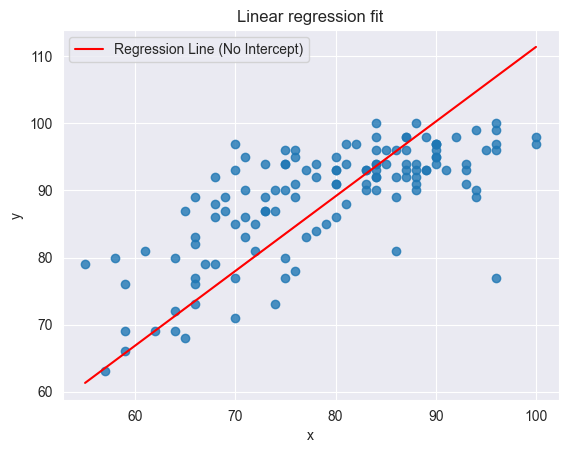

In [232]:
# Predictions with 95% confidence intervals
# ==============================================================================
predictions_noint = modelf_noint.get_prediction(exog = data_train).summary_frame(alpha=0.05)
predictions_noint['x'] = X_train[:, 0]
predictions_noint['y'] = y_train
predictions_noint = predictions_noint.sort_values('x')

# Graph
# ==============================================================================
sns.regplot(    
    x     = 'x',
    y     = 'y',
    data  = predictions_noint,
    fit_reg = False
).set_title('Linear regression fit');
sns.lineplot(x='x', y='mean', data=predictions_noint, color='red', label='Regression Line (No Intercept)');

## Model error test

Perhaps one of the best indicators that our model is valid and can be used reliably is the root mean square error (`rmse`) of the residues. As a rule of thumb, the `rmse` should be less than 10% of the mean of the predicted variable.

#### Model with intercept

In [233]:
# Model error test
# ==============================================================================
#X_test = sm.add_constant(X_test, prepend=False)
predictions = modelf.predict(exog = data_test)
rmse = root_mean_squared_error(
        y_true  = y_test,
        y_pred  = predictions
       )
print("")
print(f"The test error (rmse) is {rmse}, which is {rmse/mean_predicted_variable*100:.2f}% of the mean of `Rotten_Tomatoes`.")


The test error (rmse) is 4.13733336293946, which is 4.65% of the mean of `Rotten_Tomatoes`.


#### Model with no intercept

In [234]:
# Model error test
# ==============================================================================
#X_test = sm.add_constant(X_test, prepend=False)
predictions_noint = modelf_noint.predict(exog = data_test)
rmse = root_mean_squared_error(
        y_true  = y_test,
        y_pred  = predictions_noint
       )
print("")
print(f"The test error (rmse) is {rmse}, which is {rmse/mean_predicted_variable*100:.2f}% of the mean of `Rotten_Tomatoes`.")


The test error (rmse) is 8.31873445396862, which is 9.35% of the mean of `Rotten_Tomatoes`.


In both cases, the `rmse` is low, snaller than 10% of the mean of `Rotten_Tomatoes`. This suggests that, our chosen predictor may be a good choice, although there could be other variables that influence the value of the predicted variable (which is the case, since we ignored all the other variables in this analysis).

## Interpreting the results (Model with intercept)

The `coef` column in the regression table gives the estimated value for both of the parameters of the linear model ($\hat{a}$ and $\hat{b}$). These correspond to the intercept and the slope of the line. Standard errors, $t$-statistic value and $p$-value for each of the parameters is also shown. This allows us to determine if the predictors are significantly different than 0, that is, they are important for the model. We see that such *$p$-values* are smaller than 0.05.

`R-squared` indicates that the model is able to explain 42.5% of the observerd variability for the response variable. Furthermore, the *$p$-value* obtained in the F-test (`Prob (F-statistic) = 6.31e-46`) indicates that there is sufficient evidence that the variance explained by the model is greater than that of random chance.

So, the linear model thus generated follows the equation:

$$Rotten_Tomatoes = 44.17 + 0.5656\, Metacritic$$
 
For each point of increment in `Metacritic`, the `Rotten_Tomatoes` score increases by 0.7995 **on average**

The model error test is about $5.8$, so the model predictions get farther from the real value by $5.8$ points **on average**. This error is slightly less than 10% the average of `Rotten_Tomatoes`, so we can conclude the regression is valid.

## Making a prediction

Now, we will use our model to predict the `Revenue` of a movie that is not in the data frame. To that end, we create a list with all movie titles from our dataset, so that we can verify if our chosen test titles are in said dataset.

In [238]:
titles = movies_Metacritic.index.values.tolist()

In [239]:
'American Fiction' in titles or 'Babylon' in titles or 'Furiosa: A Mad Max Saga' in titles or 'Do the Right Thing' in titles\
or 'Juror #2'.title() in titles or "Uncut Gems".title() in titles

False

Our chosen titles are not in the dataset. Next, we create a dataframe with the necessary information to make a prediction using our model. We will include, besides the `Title` of the movie, their `Year` of release, `Runtime`, `Budget`, `Revenue`, `IMDb`, `Rotten_Tomatoes`, `Metacritic` and `Filmaffinity` ratings, and our `Personal` rating.

In [240]:
favorites = pd.DataFrame({'Year':[2023,2022,2024,1989,2024 ], 
                          'Runtime':[117,189,148,120,116],\
                          'Budget':[10,78,168,6.2,30],\
                          'Revenue':[23.026243,64.9,174.3,37.3,20.4],\
                          'Personal':[85,93,97,88,85],\
                          'IMDb':[75,71,75,80,70],\
                          'Rotten_Tomatoes':[93,57,90,92,93],\
                          'Metacritic':[81,61,58,93,72],\
                          'Filmaffinity':[67,69,67,73,68]},
                         index=['American Fiction','Babylon',"Furiosa: A Mad Max Saga",'Do the Right Thing','Juror #2'])
favorites

,Year,Runtime,Budget,Revenue,Personal,IMDb,Rotten_Tomatoes,Metacritic,Filmaffinity
American Fiction,2023,117,10.0,23.026243,85,75,93,81,67
Babylon,2022,189,78.0,64.900000,93,71,57,61,69
Furiosa: A Mad Max Saga,2024,148,168.0,174.300000,97,75,90,58,67
Do the Right Thing,1989,120,6.2,37.300000,88,80,92,93,73
Juror #2,2024,116,30.0,20.400000,85,70,93,72,68


In [241]:
modelf.predict(exog = favorites)

American Fiction           89.986774
Babylon                    78.674982
Furiosa: A Mad Max Saga    76.978213
Do the Right Thing         96.773849
Juror #2                   84.896468
dtype: float64

In [242]:
modelf_noint.predict(exog = favorites)

American Fiction            90.255287
Babylon                     67.970031
Furiosa: A Mad Max Saga     64.627242
Do the Right Thing         103.626440
Juror #2                    80.226921
dtype: float64

Our predictions are slightly overestimated, although the model with intercept gives better numbers. This confirms that there are other variables that influence the value of the predicted variable (which is the case, since we ignored all the other variables in this analysis)

## References

Regresión lineal con Python by Joaquín Amat Rodrigo, available under a Attribution 4.0 International (CC BY 4.0) at https://www.cienciadedatos.net/documentos/py10-regresion-lineal-python.html